In [111]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss
from pmdarima.arima.utils import ndiffs, nsdiffs
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA
from statsmodels.tsa.seasonal import seasonal_decompose

## Setup

In [101]:
RED, YELLOW = '#E4002B', '#FFAA00'

In [102]:
def pmc_rn() -> pd.DataFrame:
    pmc = pd.read_csv(
        "https://github.com/padsInsper/202632-fa/releases/download/data/pmc_volume_uf.csv",
        parse_dates=["data"],
    )
    rn_pmc_df = pmc[pmc["uf"] == "Rio Grande do Norte"].reset_index(drop=True)
    return rn_pmc_df


In [103]:
raw_df = pmc_rn()

In [104]:
print(raw_df.describe())

print(raw_df.head())

                             data  volume_idx
count                         266  266.000000
mean   2015-01-15 16:09:01.353383   92.208187
min           2004-01-01 00:00:00   38.359800
25%           2009-07-08 18:00:00   81.407485
50%           2015-01-16 12:00:00   96.978560
75%           2020-07-24 06:00:00  103.982408
max           2026-02-01 00:00:00  145.158040
std                           NaN   19.951761
                    uf       data  volume_idx
0  Rio Grande do Norte 2004-01-01    39.31165
1  Rio Grande do Norte 2004-02-01    38.35980
2  Rio Grande do Norte 2004-03-01    43.78538
3  Rio Grande do Norte 2004-04-01    41.97685
4  Rio Grande do Norte 2004-05-01    44.26130


## Análise descritiva

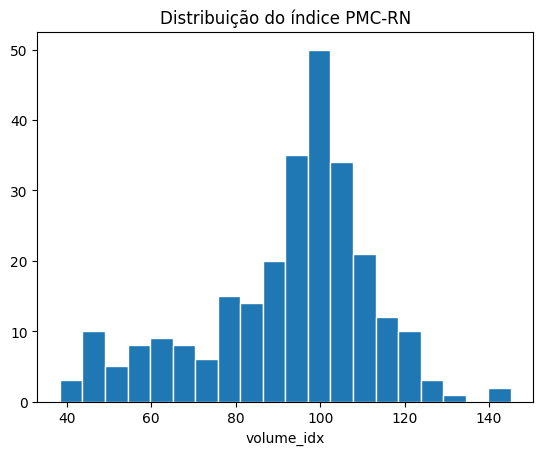

In [105]:
plt.hist(raw_df['volume_idx'], bins=20, edgecolor='white')
plt.title("Distribuição do índice PMC-RN")
plt.xlabel("volume_idx")
plt.show()

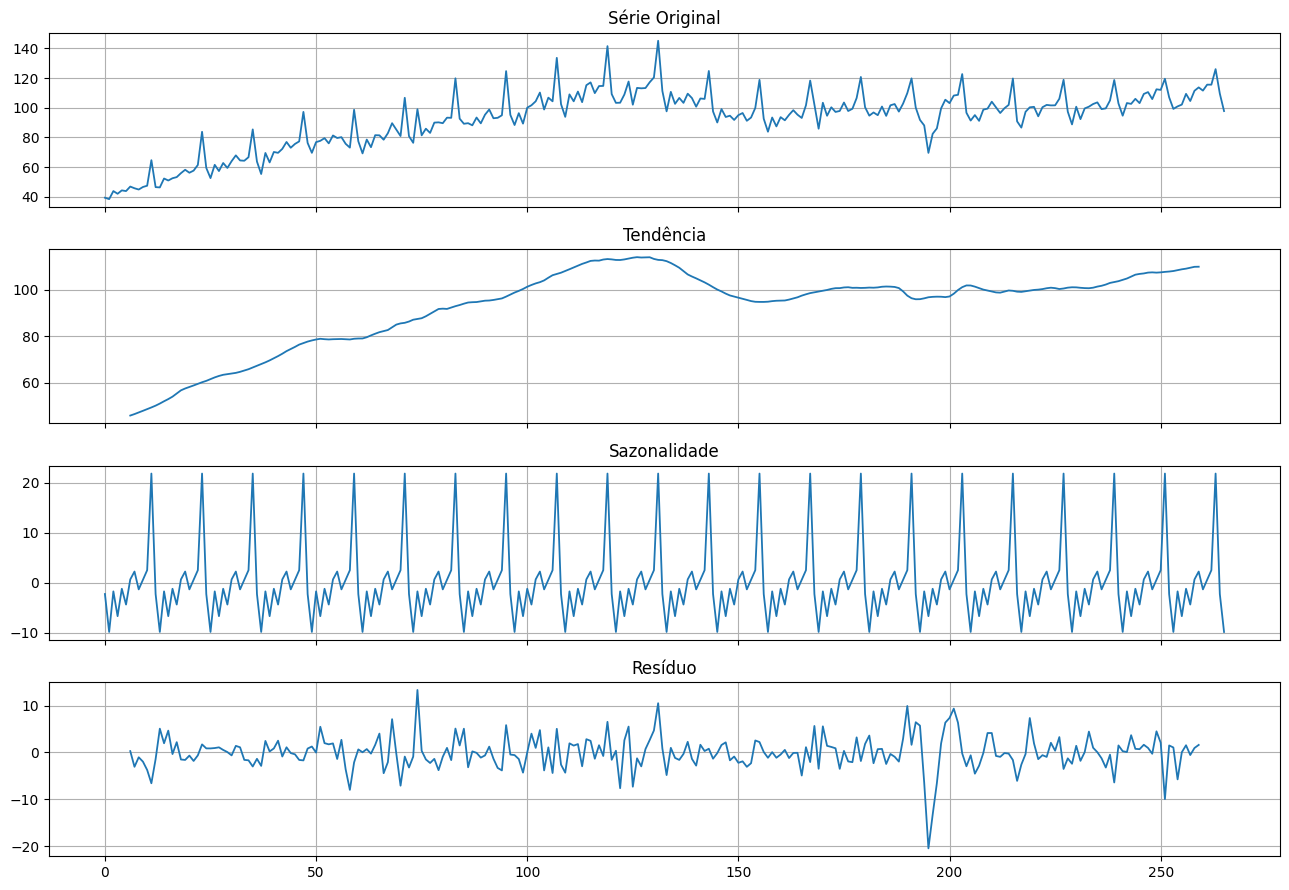

In [112]:
decomp = seasonal_decompose(raw_df["volume_idx"], model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(13, 9), sharex=True)
labels = ['Série Original', 'Tendência', 'Sazonalidade', 'Resíduo']
components = [decomp.observed, decomp.trend, decomp.seasonal, decomp.resid]

for ax, comp, label in zip(axes, components, labels):
    ax.plot(comp, linewidth=1.3)
    ax.set_title(label)
    ax.grid(True)

plt.tight_layout()
plt.show()

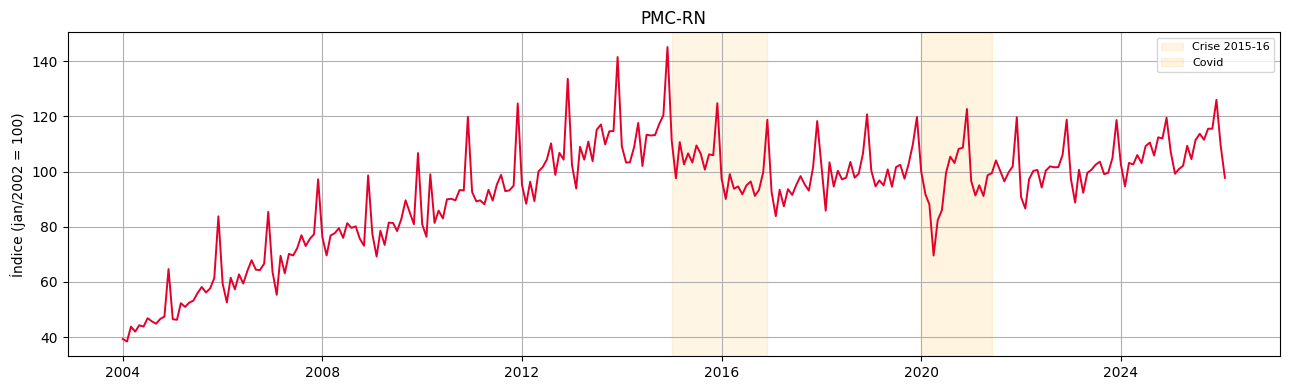

In [106]:
# ACF

fig, ax = plt.subplots(figsize=(13, 4))

ax.plot(raw_df["data"], raw_df["volume_idx"], color=RED, linewidth=1.4)
ax.set_title("PMC-RN")
ax.set_ylabel("Índice (jan/2002 = 100)")
ax.grid(True)

# Crise 2015-2016
ax.axvspan(
    pd.Timestamp("2015-01-01"),
    pd.Timestamp("2016-12-01"),
    alpha=0.1,
    color="orange",
    label="Crise 2015-16",
)

# Covid-19
ax.axvspan(
    pd.Timestamp("2020-01-01"),
    pd.Timestamp("2021-06-01"),
    alpha=0.12,
    color=YELLOW,
    label="Covid",
)
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

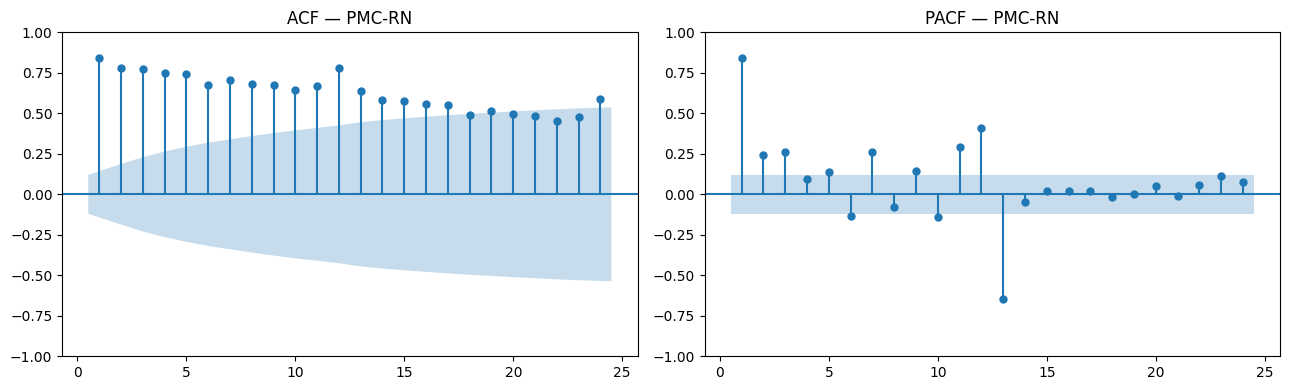

In [107]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_acf(raw_df["volume_idx"],  ax=axes[0], lags=24, zero=False, title="ACF — PMC-RN")
plot_pacf(raw_df["volume_idx"], ax=axes[1], lags=24, zero=False, title="PACF — PMC-RN")
plt.tight_layout()
plt.show()

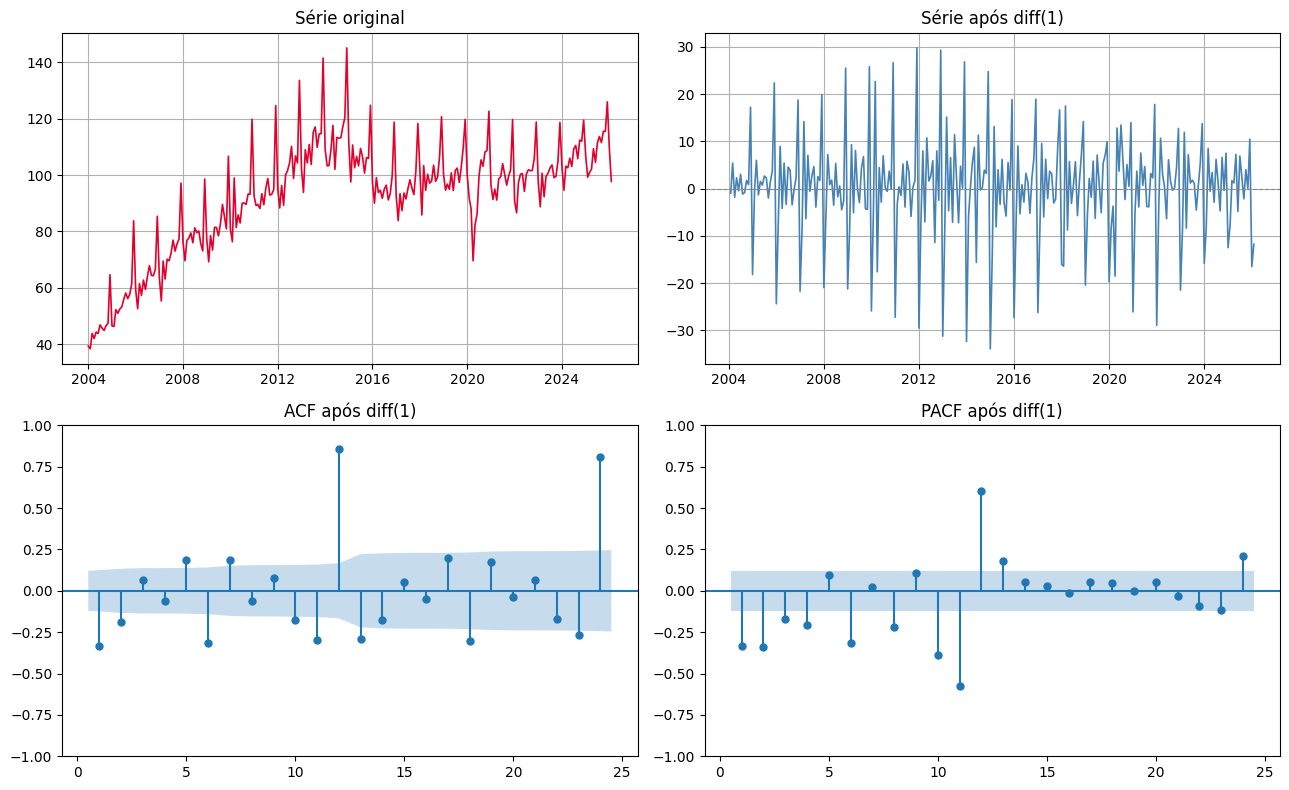

In [113]:
y = raw_df["volume_idx"]
y_diff = y.diff(1).dropna()

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# Série no nível
axes[0, 0].plot(raw_df["data"], y, color="#E4002B", linewidth=1.2)
axes[0, 0].set_title("Série original")
axes[0, 0].grid(True)

# Série diferenciada
axes[0, 1].plot(raw_df["data"].iloc[1:], y_diff, color="steelblue", linewidth=1.2)
axes[0, 1].axhline(0, color="#888", linestyle="--", linewidth=0.8)
axes[0, 1].set_title("Série após diff(1)")
axes[0, 1].grid(True)

# ACF e PACF da série diferenciada
plot_acf(y_diff, ax=axes[1, 0], lags=24, zero=False, title="ACF após diff(1)")
plot_pacf(y_diff, ax=axes[1, 1], lags=24, zero=False, title="PACF após diff(1)")

plt.tight_layout()
plt.show()


In [109]:
adf = adfuller(raw_df["volume_idx"])
print(f"ADF p-value: {adf[1]:.4f}")

kpss_stat, kpss_p, *_ = kpss(raw_df["volume_idx"], regression="ct")
print(f"KPSS p-value: {kpss_p:.4f}")

print(f"ndiffs:  {ndiffs(raw_df['volume_idx'], test='adf')}")
print(f"nsdiffs: {nsdiffs(raw_df['volume_idx'], m=12)}")

ADF p-value: 0.0494
KPSS p-value: 0.0100
ndiffs:  1
nsdiffs: 0


/tmp/ipykernel_309038/110181414.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(raw_df["volume_idx"], regression="ct")


## Modelagem

In [94]:
df_sf = (
    raw_df.rename(columns={"uf": "unique_id", "data": "ds", "volume_idx": "y"})[
        ["unique_id", "ds", "y"]
    ]
    .assign(ds=lambda d: pd.to_datetime(d["ds"]))
    .reset_index(drop=True)
)

In [95]:
sf = StatsForecast(
    models=[AutoARIMA(season_length=12)],
    freq="MS",
)
sf.fit(df_sf)

StatsForecast(models=[AutoARIMA])

In [114]:
modelo = sf.fitted_[0, 0].model_

# arma = (p, q, P, Q, m, d, D)
p, q, P, Q, m, d, D = modelo["arma"]

print(f"Modelo selecionado: SARIMA({p},{d},{q})({P},{D},{Q})[{m}]")
print(f"AIC: {modelo['aic']:.2f}")

Modelo selecionado: SARIMA(0,1,2)(1,1,2)[12]
AIC: 1445.10


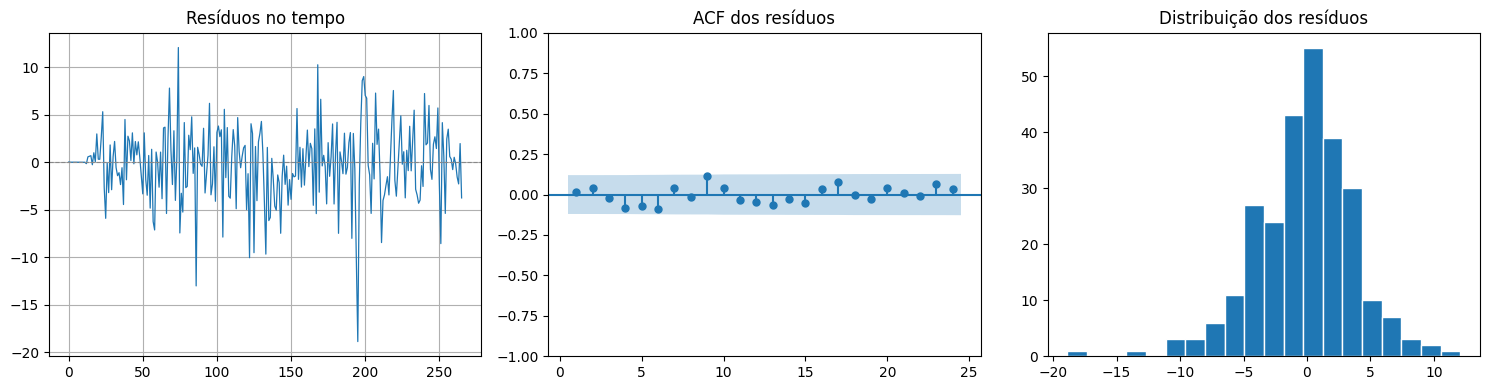

In [115]:
modelo = sf.fitted_[0, 0].model_
residuos = pd.Series(modelo.get("residuals", []))

if len(residuos) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot(residuos.values, linewidth=0.9)
    axes[0].axhline(0, color="#888", linestyle="--", linewidth=0.8)
    axes[0].set_title("Resíduos no tempo")
    axes[0].grid(True)

    plot_acf(residuos, ax=axes[1], lags=24, zero=False, title="ACF dos resíduos")

    axes[2].hist(residuos, bins=20, edgecolor="white")
    axes[2].set_title("Distribuição dos resíduos")

    plt.tight_layout()
    plt.show()
else:
    print("Resíduos não disponíveis no modelo.")


## Previsão · 24 meses à frente

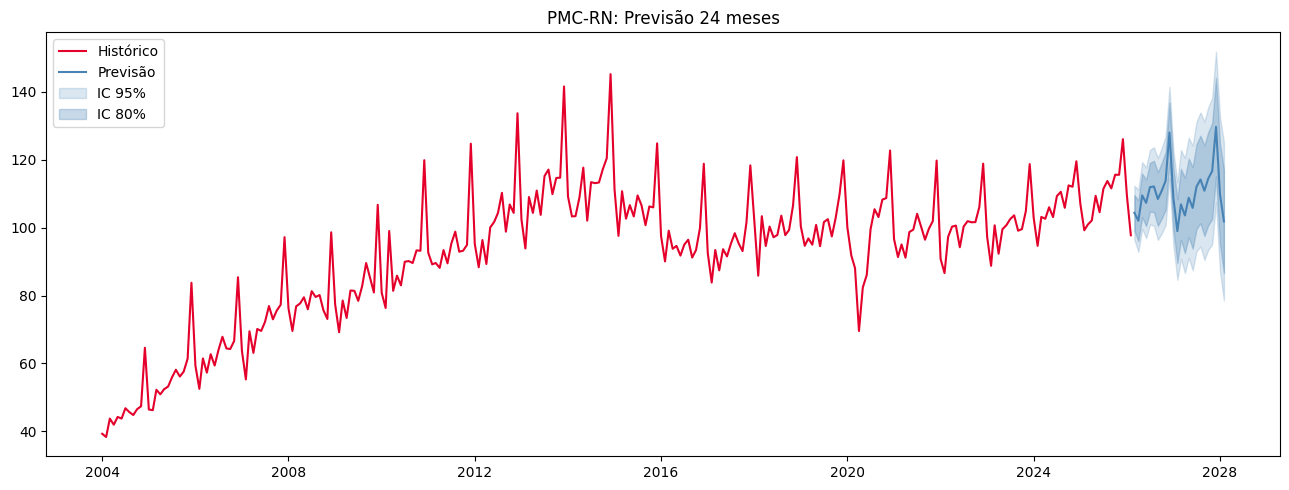

In [97]:
forecast = sf.predict(h=24, level=[80, 95])

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(df_sf["ds"], df_sf["y"], label="Histórico", color=RED)
ax.plot(forecast["ds"], forecast["AutoARIMA"], label="Previsão", color="steelblue")
ax.fill_between(
    forecast["ds"],
    forecast["AutoARIMA-lo-95"],
    forecast["AutoARIMA-hi-95"],
    alpha=0.2,
    color="steelblue",
    label="IC 95%",
)
ax.fill_between(
    forecast["ds"],
    forecast["AutoARIMA-lo-80"],
    forecast["AutoARIMA-hi-80"],
    alpha=0.3,
    color="steelblue",
    label="IC 80%",
)
ax.legend()
ax.set_title("PMC-RN: Previsão 24 meses")
plt.tight_layout()
plt.show()


## Discussão

**1. O ACF/PACF da série original sugeriu sazonalidade? E tendência? Bate com o que você viu no gráfico de linha?**

Sim, ambos os diagnósticos se confirmam. O gráfico de linha exibe crescimento contínuo de ~40 para ~145 entre 2004 e 2026, com interrupções visíveis na crise 2015-16 e no Covid.
A ACF no nível decai muito lentamente: lags 1 a 24 todos significativos, sinal claro de não-estacionariedade por tendência. 
Picos salientes nos lags 12 e 24 da ACF revelam sazonalidade anual: queda em jan/fev (pós-13º salário) e alta em nov/dez.
A decomposição clássica confirma: há tendência ascendente suave e um padrão sazonal estável que se repete todo ano.

**2. Quantas diferenças (regular e sazonal) o AutoARIMA aplicou? E os componentes AR/MA? Conseguiu observar isso no ACF/PACF?**

- O modelo selecionado foi **SARIMA(0,1,2)(1,1,2)[12]** com AIC = 1445.10.
- Foram aplicadas 1 diferença regular (d=1) e 1 diferença sazonal (D=1), embora o `nsdiffs` automático tenha retornado 0, o AutoARIMA identificou estrutura sazonal residual e optou pela diferença sazonal.
- Do lado não-sazonal: p=0 (sem AR) e q=2 (dois termos MA), sugerindo que após a diferenciação o ACF corta abruptamente em 2 lags. 
- Do lado sazonal: P=1 (AR sazonal) e Q=2 (dois MA sazonais), condizente com os picos que aparecem nos lags 12 e 24 do ACF/PACF após diff(1).

**3. Os resíduos parecem white noise? Algum padrão remanescente sazonal?**

Sim, os resíduos se comportam como ruído branco.
O gráfico no tempo oscila em torno de zero sem tendência ou heteroscedasticidade visível.
O ACF dos resíduos não apresenta barras significativas nos lags sazonais (12, 24), indicando que a estrutura sazonal foi capturada pelo modelo. A distribuição é aproximadamente simétrica em torno de zero, sem caudas excessivamente pesadas. O modelo absorveu bem a dinâmica da série.

**4. A previsão pareceu razoável visualmente?**

Sim, a previsão de 24 meses reproduz o padrão sazonal anual, mantendo os picos de fim de ano e as quedas do início do ano. 
A série se ancora bem no último valor histórico sem saltos abruptos. Os intervalos de confiança de 80% e 95% abrem progressivamente com o horizonte, mas de forma moderada, sem explodir. O nível geral da previsão é coerente com a trajetória recente de crescimento moderado observada na série.

**5. Que outras UFs você imagina que dariam um SARIMA bem diferente do seu (e por quê)?**

São Paulo provavelmente teria um modelo com menor volatilidade sazonal relativa, dada a maior diversificação do varejo e economia mais robusta, sazonalidade existe, mas amortecida. 
E o Amazonas seria bem diferente pelo calendário da Zona Franca de Manaus, que gera ciclos industriais específicos sem correspondência no restante do Brasil.